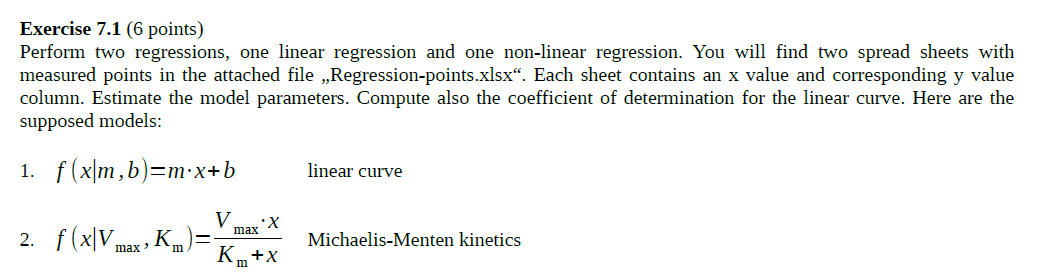

Linear Regression

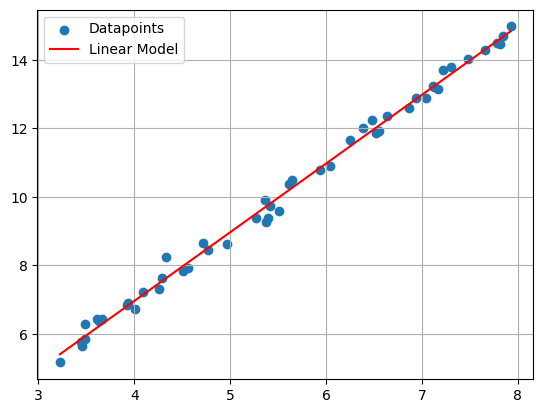

m:  2.005516260006859 b:  -1.0597558448937257 R^2:  0.9948269589219741
18.995406755174862


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel("Regression-points.xlsx", sheet_name="Linear")
x, y = df["X"], df["Y"]

x_mean, y_mean = x.mean(), y.mean()

m = sum(x * (y - y_mean)) / sum(x * (x - x_mean))
b = y_mean - m * x_mean

xmod = np.arange(min(x), max(x), 0.001)
ymod = m * xmod + b

plt.scatter(x, y, label = "Datapoints")
plt.plot(xmod, ymod, color = "red", label = "Linear Model")
plt.legend()
plt.grid()
plt.show()

r_squared = 1 - sum((y - (m * x + b)) ** 2) / sum((y - y_mean) ** 2)

print("m: ", m,"b: " ,b, "R^2: ", r_squared)

extrapolated_x_10 = m * 10 + b


print(extrapolated_x_10)

Non-Linear Regression

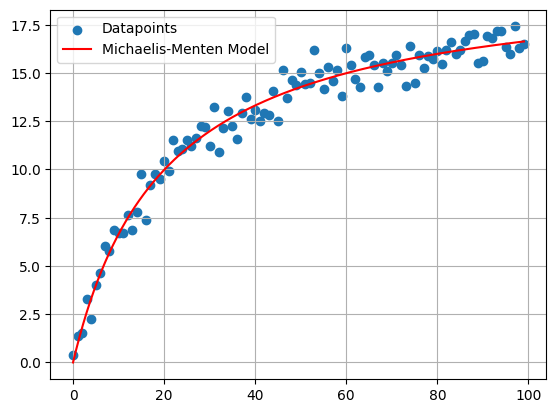

17.329725181746706
[20.01016232 20.10746419]


In [ ]:
from scipy.optimize import leastsq

df = pd.read_excel("Regression-points.xlsx", sheet_name="Nonlinear")
x, y = df["X"], df["Y"]

def michaelis_menten(par, X, Y):
  V_max, K_m = par
  return V_max * X / (K_m + X) - Y

start_par = [1, 1]

result = leastsq(michaelis_menten, start_par, args = (x, y))

xmod = np.arange(min(x), max(x), 0.001)
ymod = michaelis_menten(result[0], xmod, 0)

plt.scatter(x, y, label = "Datapoints")
plt.plot(xmod, ymod, color = "red", label = "Michaelis-Menten Model")
plt.legend()
plt.grid()
plt.show()

extrapolated_x_130 = michaelis_menten(result[0], 130, 0)

print(extrapolated_x_130)
print(result[0])